# Ejemplo Ilustrativo de Perfiles de Influencia

Este notebook implementa el ejemplo de la Sección 6 de la tesis sobre perfiles de influencia usando valores SHAP.

Tenemos:
- **N = 10** observaciones
- **n = 3** variables: `age` (x₁), `sex_isFemale` (x₂), `systolic_blood_pressure` (x₃)
- Variable de interés: **age**
- División en **2 percentiles** de 5 observaciones cada uno

In [1]:
import os
import sys
import numpy as np
import pandas as pd

from cgt_perezsechi.visualization.plot import plot_shap_distribution
from cgt_perezsechi.modeling.inequality import gini_coefficient
from cgt_perezsechi.visualization.plot import plot_shap_lorenz_curve

## 1. Creación del Dataset

Creamos el conjunto de datos de ejemplo con los valores SHAP correspondientes.

In [6]:
# Crear el dataset
X_shapley = pd.DataFrame({
    'age': [30, 32, 35, 41, 44, 50, 55, 61, 68, 72],
    'sex_isFemale': ['false', 'false', 'true', 'false', 'false', 'false', 'true', 'true', 'true', 'false'],
    # 'sex_isFemale': [0, 0, 1, 0, 0, 0, 1, 1, 1, 0],
    'systolic_blood_pressure': [180, 190, 185, 200, 210, 220, 215, 240, 230, 225]
})

shap_values = np.array([
    [-0.8, -1.2, -1.5, -0.9, -0.5, 0.6, 1.4, 2.5, 1.8, 2.2],
    [0.2, 0.3, 0.1, 0.4, 0.5, 0.6, -0.2, -0.4, 0.1, 0.3],
    [-0.1, 0.0, 0.2, -0.3, 0.1, 0.4, 0.3, -0.2, 0.5, 0.1]
]).T

n_bins = 5

Variable: age


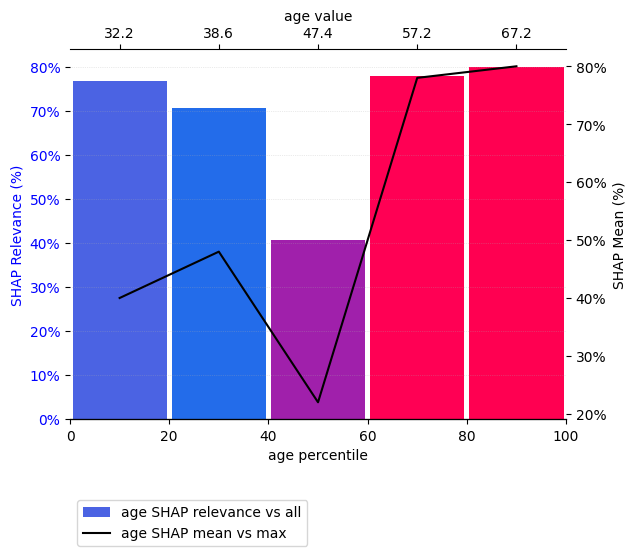

{'abs_shap_relevance': array([76.92307692, 70.58823529, 40.74074074, 78.        , 80.        ]),
 'abs_shap_mean_vs_max': array([40., 48., 22., 78., 80.]),
 'variable_label': array([32.2, 38.6, 47.4, 57.2, 67.2]),
 'norm_shap_mean': array([0.25  , 0.2   , 0.5125, 0.9875, 1.    ])}

In [3]:
variable_name = 'age'
print(f"Variable: {variable_name}")
plot_shap_distribution(variable_name, X_shapley, shap_values, n_bins)

Variable: sex_isFemale


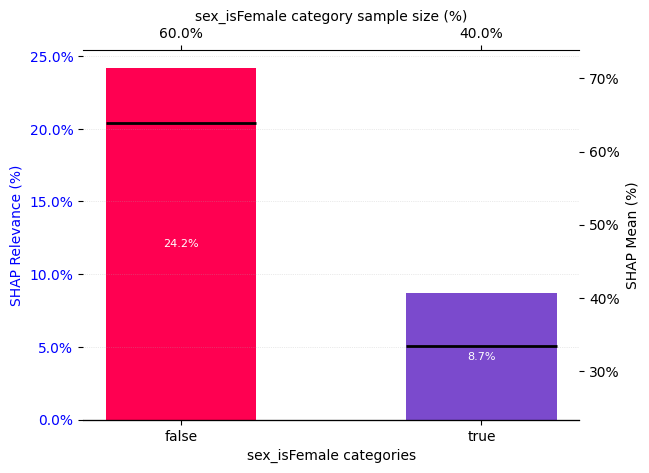

{'abs_shap_relevance': array([24.21052632,  8.69565217]),
 'abs_shap_mean_vs_max': array([63.88888889, 33.33333333]),
 'variable_label': ['60.0%', '40.0%'],
 'norm_shap_mean': array([1.        , 0.36956522])}

In [7]:
variable_name = 'sex_isFemale'
print(f"Variable: {variable_name}")
plot_shap_distribution(variable_name, X_shapley, shap_values, n_bins)

## Lorenz Curve for the most relevant variables using Normalized SHAP Values

In [8]:
# Crear el dataset
X_shapley = pd.DataFrame({
    'age': [30, 32, 35, 41, 44, 50, 55, 61, 68, 72],
    # 'sex_isFemale': ['false', 'false', 'true', 'false', 'false', 'false', 'true', 'true', 'true', 'false'],
    'sex_isFemale': [0, 0, 1, 0, 0, 0, 1, 1, 1, 0],
    'systolic_blood_pressure': [180, 190, 185, 200, 210, 220, 215, 240, 230, 225]
})

shap_values = np.array([
    [-0.8, -1.2, -1.5, -0.9, -0.5, 0.6, 1.4, 2.5, 1.8, 2.2],
    [0.2, 0.3, 0.1, 0.4, 0.5, 0.6, -0.2, -0.4, 0.1, 0.3],
    [-0.1, 0.0, 0.2, -0.3, 0.1, 0.4, 0.3, -0.2, 0.5, 0.1]
]).T

n_bins = 5

Gini coefficient for age SHAP values: 0.4355


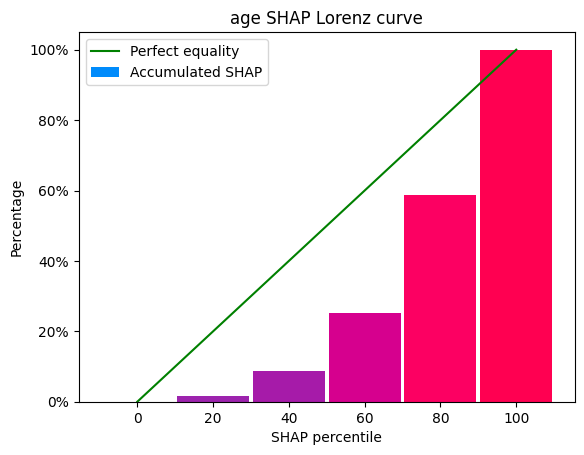

Gini coefficient for sex_isFemale SHAP values: 0.0953


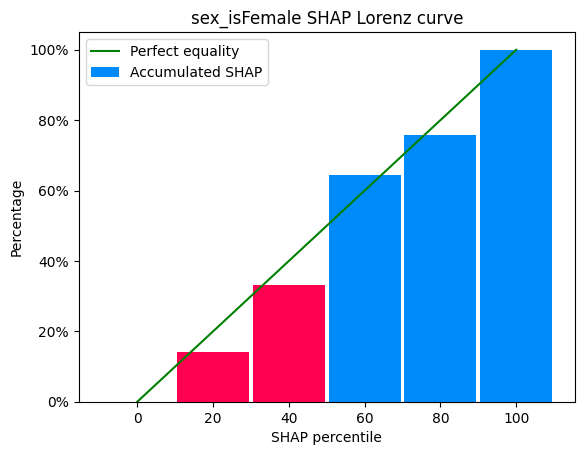

Gini coefficient for systolic_blood_pressure SHAP values: 0.0875


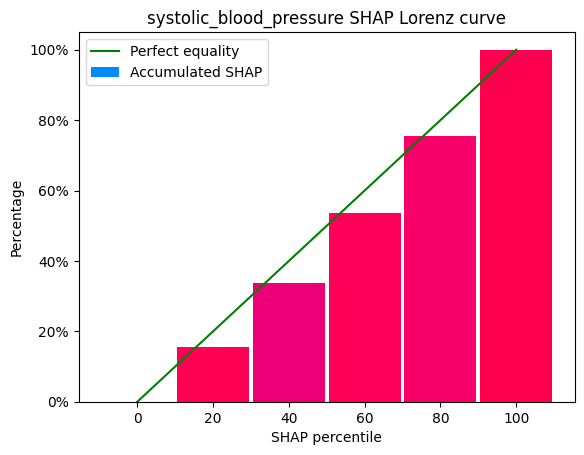

In [9]:
# top_variables = shap_top_important_features(shap_values, X, 15)
top_variables = [
    'age',
    'sex_isFemale',
    'systolic_blood_pressure'
]


norm_shap_values = (shap_values - np.min(shap_values)) / \
    (np.max(shap_values) - np.min(shap_values))
abs_shap_values = np.abs(shap_values)

for variable_name in top_variables:
    variable_index = X_shapley.columns.get_loc(variable_name)
    variable_shap_values = norm_shap_values[:, variable_index]

    gini_index = gini_coefficient(variable_shap_values)
    print(f"Gini coefficient for {variable_name} SHAP values: {gini_index:.4f}")
    plot_shap_lorenz_curve(variable_name, X_shapley, norm_shap_values, n_bins)